# Convolutional Neural Networks and Transfer Learning

Three computer-vision exercises with TensorFlow/Keras:

1. **CIFAR-10 classification** - a simple CNN as baseline, then a deeper CNN with max pooling and dropout aiming at more than 75% validation accuracy.
2. **Transfer learning** - binary classification (horses vs. humans) with a ResNet50 pretrained on ImageNet, comparing feature extraction (frozen backbone) against full fine-tuning, with data augmentation.
3. **Object localization** - bounding-box regression on Fashion-MNIST, evaluated with an IoU-based accuracy.

Cells marked `# Provided by course materials` contain scaffolding supplied with the assignment; the remaining code and the written analysis are my own.

*Coursework - BSc in Applied Data Science, Universitat Oberta de Catalunya (UOC), Machine Learning course. Narrative translated to English from the original Spanish; printed outputs and figure labels are shown as originally executed (in Spanish).*

## Setup

In [1]:
! pip install -q matplotlib tensorflow numpy scikit-image

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from skimage.transform import resize
import matplotlib.pyplot as plt

In [3]:
print('Check GPU runtime type... ')
if len(tf.config.list_physical_devices('GPU')) == 0:
  print('Change Runtype Type in top menu for GPU acceleration')
else:
  print('OK!')

Check GPU runtime type... 
OK!


## 1. Image classification on CIFAR-10

### 1.1 Loading the data

(32, 32, 3)
Forma de los datos originales de entremiento: (50000, 32, 32, 3)
Forma de los datos originales de prueba: (10000, 32, 32, 3)


(-0.5, 31.5, 31.5, -0.5)

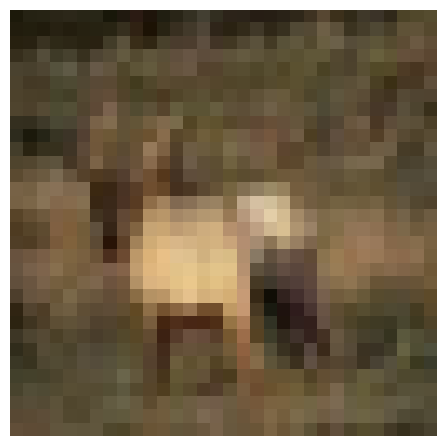

In [4]:
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = cifar10.load_data()

print(x_train_orig[0].shape)
# We check the size of the original data
print("Forma de los datos originales de entremiento: {}".format(x_train_orig.shape))
print("Forma de los datos originales de prueba: {}".format(x_test_orig.shape))

# We visualize the first image of the training set
second_image = x_train_orig[3]
second_image = np.array(second_image, dtype='float')
pixels = second_image.reshape((32, 32, 3))
plt.imshow(pixels/255, cmap='brg')
plt.tight_layout()
plt.axis('off')

### 1.2 Data preparation

In [5]:
# We find the minimum and maximum values in the training set
v_min = np.min(x_train_orig)
v_max = np.max(x_train_orig)
print("Los valores mín. y máx. antes de la normalización son {} y {}.".format(v_min, v_max))

# Normalization between 0 and 1
x_train_orig = (x_train_orig - v_min) / (v_max - v_min)
x_test_orig = (x_test_orig - v_min) / (v_max - v_min)

print("Los valores mín. y máx. tras la normalización son {} y {}".format(np.min(x_train_orig), np.max(x_train_orig)))

x_train = x_train_orig.reshape(50000,32,32,3)
x_test = x_test_orig.reshape(10000,32,32,3)

print("Forma de los datos del entremiento: {}".format(x_train.shape))
print("Forma de los datos de prueba: {}".format(x_test.shape))

y_train = to_categorical(y_train_orig)
y_test = to_categorical(y_test_orig)

print("La forma de y_train_orig es {} y el valor de y_train_orig[0] es {}".format(y_train_orig.shape, y_train_orig[0]))
print("La forma de y_train es {} y el valor de y_train[0] es {}".format(y_train.shape, y_train[0]))

Los valores mín. y máx. antes de la normalización son 0 y 255.
Los valores mín. y máx. tras la normalización son 0.0 y 1.0
Forma de los datos del entremiento: (50000, 32, 32, 3)
Forma de los datos de prueba: (10000, 32, 32, 3)
La forma de y_train_orig es (50000, 1) y el valor de y_train_orig[0] es [6]
La forma de y_train es (50000, 10) y el valor de y_train[0] es [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


### 1.3 Baseline CNN: build, compile and train

In [6]:
num_classes = len(y_train[0])

# we instantiate the sequential model
model = Sequential()

# We add each layer to the model
model.add(Conv2D(64, kernel_size=3, activation="relu", input_shape=(32,32,3)))
model.add(Flatten())
model.add(Dense(num_classes, activation="softmax"))

In [7]:
# we compile the model

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [8]:
# We train the model
n_epochs = 35
mfit = model.fit(x_train, y_train, validation_data=(x_test, y_test), batch_size=128, epochs=n_epochs)

Epoch 1/35
391/391 [==============================] - 5s 8ms/step - loss: 1.5116 - accuracy: 0.4717 - val_loss: 1.2898 - val_accuracy: 0.5501
Epoch 2/35
391/391 [==============================] - 2s 6ms/step - loss: 1.2166 - accuracy: 0.5767 - val_loss: 1.2151 - val_accuracy: 0.5773
Epoch 3/35
391/391 [==============================] - 2s 6ms/step - loss: 1.0991 - accuracy: 0.6215 - val_loss: 1.1932 - val_accuracy: 0.5885
Epoch 4/35
391/391 [==============================] - 2s 5ms/step - loss: 1.0167 - accuracy: 0.6496 - val_loss: 1.1643 - val_accuracy: 0.5966
Epoch 5/35
391/391 [==============================] - 3s 7ms/step - loss: 0.9385 - accuracy: 0.6794 - val_loss: 1.1406 - val_accuracy: 0.6101
Epoch 6/35
391/391 [==============================] - 2s 6ms/step - loss: 0.8721 - accuracy: 0.6991 - val_loss: 1.1391 - val_accuracy: 0.6056
Epoch 7/35
391/391 [==============================] - 2s 6ms/step - loss: 0.8076 - accuracy: 0.7256 - val_loss: 1.1166 - val_accuracy: 0.6204
Epoch 

### 1.4 Training curves

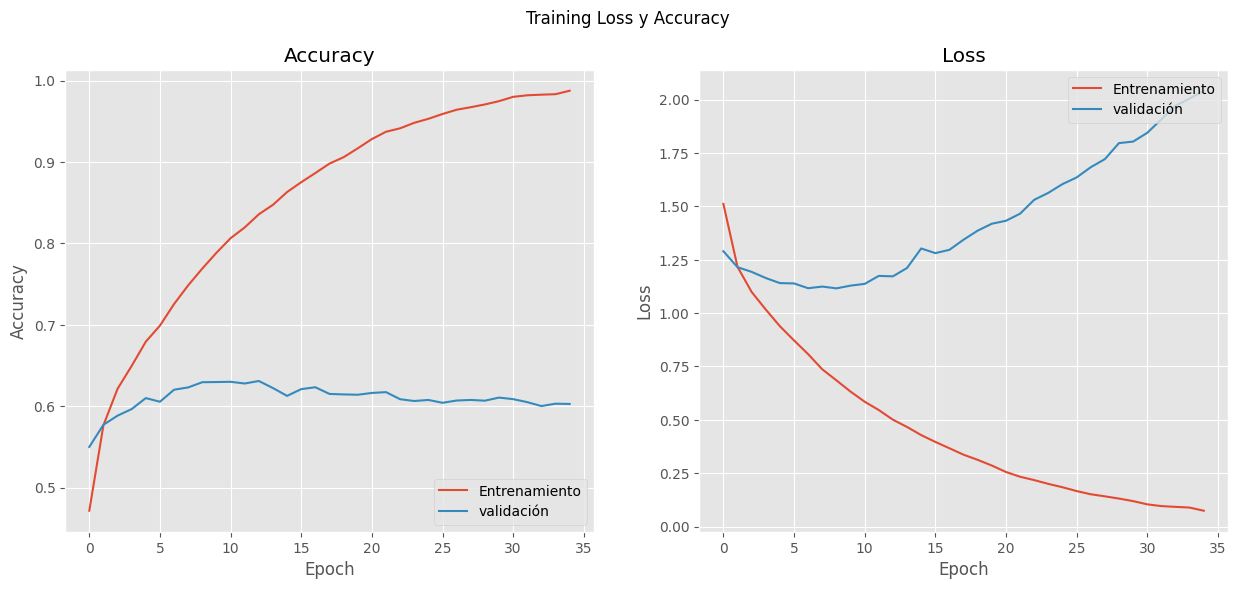

In [9]:
# on the training and validation datasets during the training of the model.

# We visualize accuracy and loss
def plot_prediction(n_epochs, mfit):
    N = n_epochs
    plt.style.use("ggplot")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
    fig.suptitle('Training Loss y Accuracy')

    ax1.plot(np.arange(0, N), mfit.history["accuracy"], label="Entrenamiento")
    ax1.plot(np.arange(0, N), mfit.history["val_accuracy"], label="validación")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend(loc="lower right")

    ax2.plot(np.arange(0, N), mfit.history["loss"], label="Entrenamiento")
    ax2.plot(np.arange(0, N), mfit.history["val_loss"], label="validación")
    ax2.set_title("Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend(loc="upper right")

    plt.show()

plot_prediction(n_epochs, mfit)

### 1.5 Analysis

From the plots and the information about the model's training, we can make several observations:

Regarding performance in training versus validation:

Accuracy: the plot shows that the "accuracy" on the training data increases steadily up to almost 100%, which is a sign of overfitting, especially because the validation "accuracy" stalls at around 60% and does not improve with additional epochs.

Loss: the training loss decreases continuously, while the validation loss increases after the first epochs. This is another clear indication of overfitting.

The model learns the training data very well, to the point of memorizing it, which results in poor performance on the validation data that the model has not seen before. This means that the model does not generalize well to new data.

It could be improved through techniques such as L1/L2 regularization, dropout, or increasing the amount of validation data used during training to help mitigate overfitting.
Reducing the complexity of the model could help prevent overfitting, by adjusting the number of layers or the number of neurons per layer.

Through Data Augmentation: when working with images, changing the scale or altering the color of the inputs can improve the model's ability to generalize.

Through Early Stopping: If we stop the training as soon as the validation loss starts to increase, even if the training loss keeps decreasing.


### 1.6 A deeper CNN (target: above 75% validation accuracy)

In [10]:
model = Sequential()


model.add(Conv2D(32, kernel_size=3, activation="relu", input_shape=(32,32,3)))
model.add(MaxPooling2D())
model.add(Conv2D(64, kernel_size=3, activation="relu"))
model.add(MaxPooling2D())
model.add(Conv2D(128, kernel_size=3, activation="relu"))
model.add(MaxPooling2D())
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation="softmax"))

In [11]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

n_epochs = 35
mfit = model.fit(x_train, y_train, validation_data=(x_test, y_test), batch_size=128, epochs=n_epochs)

Epoch 1/35
391/391 [==============================] - 8s 9ms/step - loss: 1.7989 - accuracy: 0.3279 - val_loss: 1.4734 - val_accuracy: 0.4675
Epoch 2/35
391/391 [==============================] - 3s 7ms/step - loss: 1.4368 - accuracy: 0.4754 - val_loss: 1.2527 - val_accuracy: 0.5521
Epoch 3/35
391/391 [==============================] - 3s 7ms/step - loss: 1.2896 - accuracy: 0.5352 - val_loss: 1.1573 - val_accuracy: 0.5848
Epoch 4/35
391/391 [==============================] - 3s 8ms/step - loss: 1.1949 - accuracy: 0.5740 - val_loss: 1.0518 - val_accuracy: 0.6258
Epoch 5/35
391/391 [==============================] - 3s 7ms/step - loss: 1.1255 - accuracy: 0.5990 - val_loss: 1.0155 - val_accuracy: 0.6405
Epoch 6/35
391/391 [==============================] - 3s 7ms/step - loss: 1.0599 - accuracy: 0.6240 - val_loss: 0.9464 - val_accuracy: 0.6655
Epoch 7/35
391/391 [==============================] - 3s 7ms/step - loss: 1.0108 - accuracy: 0.6408 - val_loss: 0.9415 - val_accuracy: 0.6601
Epoch 

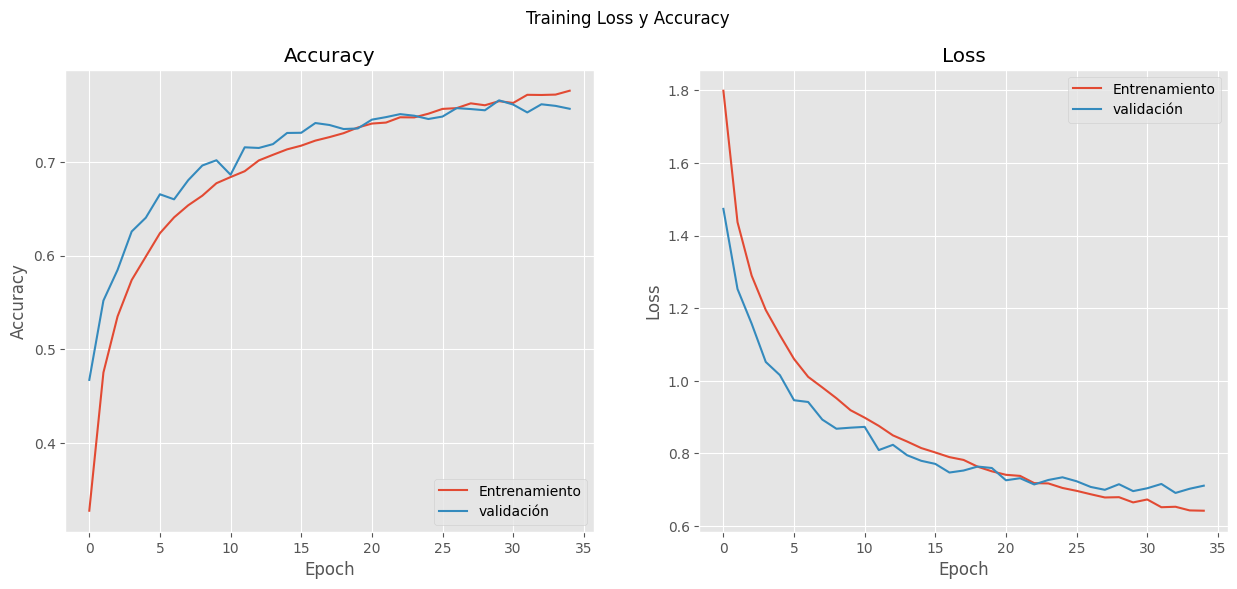

In [12]:
plot_prediction(n_epochs, mfit)

Compared with the previous results, there are significant improvements when we implement several models, in terms of validation performance:

"Accuracy" and "Loss" on the validation data stay much closer to the training results throughout the "epochs". This indicates a better balance and suggests that the model generalizes better to new data.

It prevents overfitting: the "accuracy" and "loss" values, in both training and validation, follow similar patterns. This is an indication that the measures to control overfitting are effective.

A continuous improvement is now observed:

Validation "accuracy" not only improves consistently over time but also reaches significantly higher values (close to 76% at "epoch" 35) compared with the previous ones (close to 60%).
The validation loss also shows a steady decrease, which is a healthy sign that the model is learning effectively and is not simply memorizing the training data.

Using Dropout layers has been decisive in this improvement to solve the overfitting.

## 2. Transfer learning with ResNet50: horses vs. humans

Binary classification on the [horses_or_humans](https://www.tensorflow.org/datasets/catalog/horses_or_humans) dataset (80/20 train/validation split), with images resized to 100x100 and batched.

In [13]:
# Provided by course materials
import tensorflow_datasets as tfds

tfds.disable_progress_bar()


train_ds, validation_ds = tfds.load(
    "horses_or_humans",
     # 80% for training, 20% for validation
    split=["train[:80%]", "train[80%:100%]"],
    as_supervised=True  # We include labels
)

print("Número de muestras de entrenamiento: %d" % tf.data.experimental.cardinality(train_ds))
print(
    "Número de muestras de validación: %d" % tf.data.experimental.cardinality(validation_ds)
)

Número de muestras de entrenamiento: 822
Número de muestras de validación: 205


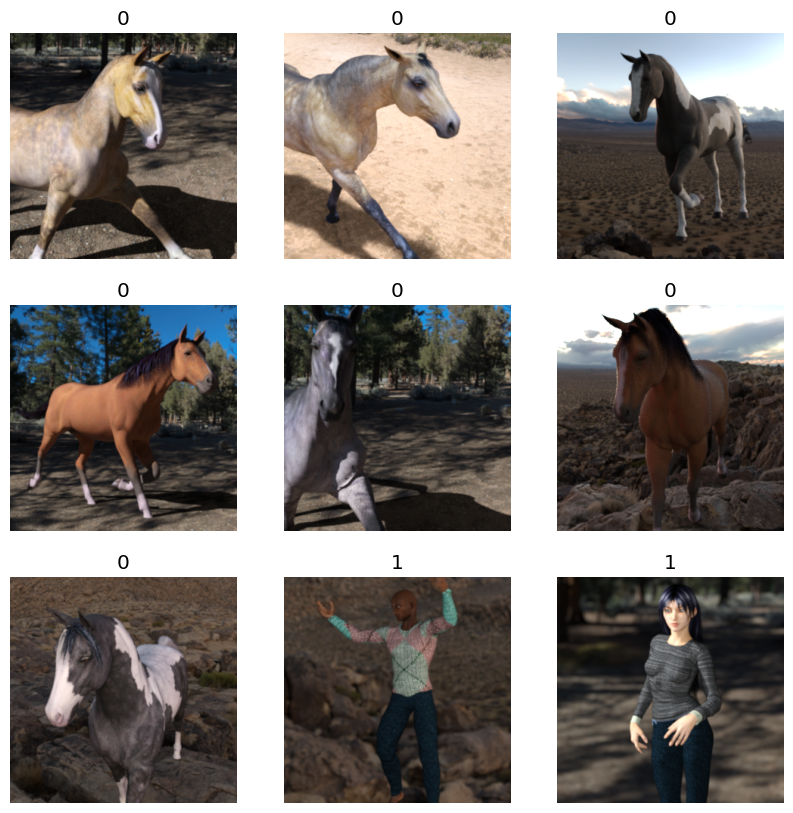

In [14]:
# Provided by course materials
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_ds.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(int(label))
    plt.axis("off")

In [15]:
# Provided by course materials
size = (100, 100)

train_ds = train_ds.map(lambda x, y: (tf.image.resize(x, size), y))
validation_ds = validation_ds.map(lambda x, y: (tf.image.resize(x, size), y))

In [16]:
# Provided by course materials
batch_size = 32

train_ds = train_ds.cache().batch(batch_size).prefetch(buffer_size=10)
validation_ds = validation_ds.cache().batch(batch_size).prefetch(buffer_size=10)

### 2.1 Data augmentation

In [17]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential(
    [layers.RandomFlip("horizontal"), layers.RandomRotation(0.1),]
)

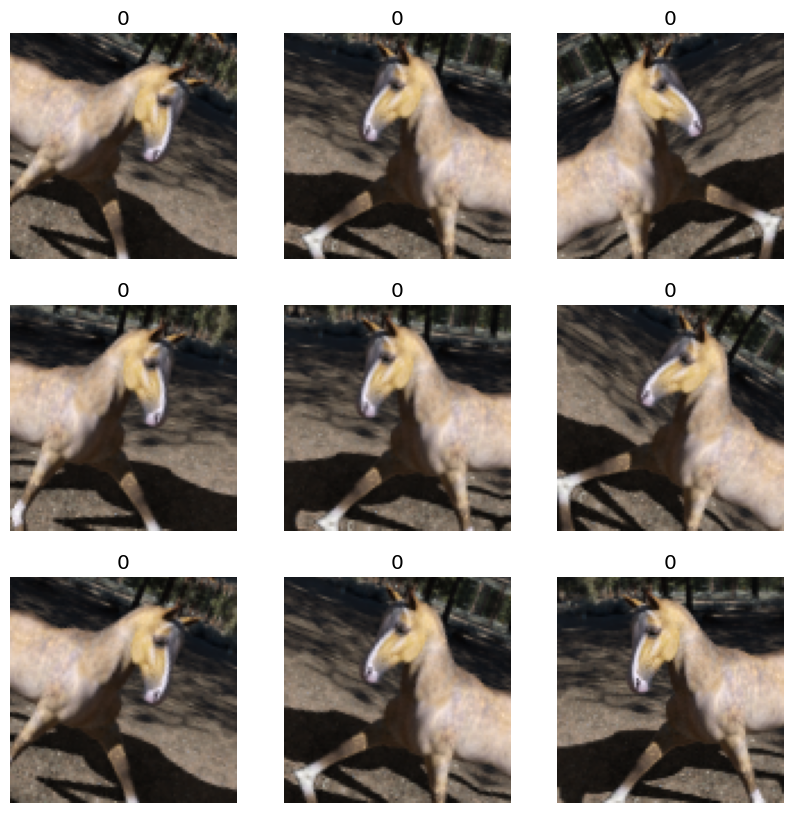

In [18]:
# code to visualize the images:
import numpy as np

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0), training=True
        )
        plt.imshow(augmented_image[0].numpy().astype("int32"))
        plt.title(int(labels[0]))
        plt.axis("off")

### 2.2 ResNet50 backbone pretrained on ImageNet

In [19]:
IMG_SHAPE = size + (3,)
base_model = tf.keras.applications.ResNet50(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               pooling='avg',
                                               weights='imagenet')

print(base_model.summary())

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 100, 100, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 106, 106, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 50, 50, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 50, 50, 64)           256       ['conv1_conv[0][0]']          
 on)                                                                                       

In [20]:
image_batch, label_batch = next(iter(train_ds))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 2048)


### 2.3 Feature extraction with a frozen backbone

In [21]:
# We prevent the weights of a given layer from being updated during training.
base_model.trainable = False


In [22]:
# We add a classification layer
# For two classes we only need one output neuron: positive numbers predict class 1, negative ones predict class 0
prediction_layer = tf.keras.layers.Dense(1)
prediction_batch = prediction_layer(feature_batch)
print(prediction_batch.shape)

(32, 1)


In [23]:
preprocess_input = tf.keras.applications.resnet.preprocess_input


inputs = tf.keras.Input(shape=(100, 100, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

print(model.summary())

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 100, 100, 3)]     0         
                                                                 
 sequential_2 (Sequential)   (None, 100, 100, 3)       0         
                                                                 
 tf.__operators__.getitem (  (None, 100, 100, 3)       0         
 SlicingOpLambda)                                                
                                                                 
 tf.nn.bias_add (TFOpLambda  (None, 100, 100, 3)       0         
 )                                                               
                                                                 
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dropout_2 (Dropout)         (None, 2048)              0     

In [24]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_ds,
                    epochs=20,
                    validation_data=validation_ds)

Epoch 1/20
26/26 [==============================] - 11s 208ms/step - loss: 0.9114 - accuracy: 0.5328 - val_loss: 0.7929 - val_accuracy: 0.7073
Epoch 2/20
26/26 [==============================] - 1s 45ms/step - loss: 0.5943 - accuracy: 0.6983 - val_loss: 0.4793 - val_accuracy: 0.8244
Epoch 3/20
26/26 [==============================] - 1s 43ms/step - loss: 0.4111 - accuracy: 0.7835 - val_loss: 0.3107 - val_accuracy: 0.9024
Epoch 4/20
26/26 [==============================] - 1s 42ms/step - loss: 0.3308 - accuracy: 0.8443 - val_loss: 0.2137 - val_accuracy: 0.9220
Epoch 5/20
26/26 [==============================] - 1s 42ms/step - loss: 0.2405 - accuracy: 0.9002 - val_loss: 0.1559 - val_accuracy: 0.9512
Epoch 6/20
26/26 [==============================] - 1s 41ms/step - loss: 0.1887 - accuracy: 0.9307 - val_loss: 0.1234 - val_accuracy: 0.9659
Epoch 7/20
26/26 [==============================] - 1s 41ms/step - loss: 0.1675 - accuracy: 0.9380 - val_loss: 0.0966 - val_accuracy: 0.9805
Epoch 8/20


The results obtained are quite good, especially in terms of how it behaves in validation. For epoch 20, we obtain the best results, in terms of minimum loss and maximum "accuracy", with:

loss: 0.0564

accuracy: 0.9818

val_loss: 0.0251

val_accuracy: 0.9951

Using an architecture based on ResNet50 as the base and only adding a couple of layers at the end (a Dropout and a classification layer with a single neuron), indicates that most of the feature learning is being handled by the pretrained ResNet50.

Regarding the non-trainable layers: we can observe that almost all of the model's parameters are non-trainable (23,587,712 out of 23,589,761), which means that the model is using pretrained weights and is only adjusting a small part of them in the last layers.

Regarding the training results: the model improves quickly, as shown by the significant decrease in the loss and the increase in "accuracy" over the "epochs". It starts with a training "accuracy" of 53.28% and a loss of 0.9114, and improves until it reaches an "accuracy" of 98.18% with a loss of only 0.0564 in just 20 "epochs".

For the validation data: the model not only follows the improvement pattern of the training, but outperforms it from the first "epochs", reaching an "accuracy" of 99.51% and a loss of 0.0251 at the end of training. This is a sign that the model is very effective at generalizing to new data.



### 2.4 Fine-tuning all weights

In [25]:
base_model.trainable = True

# We add a classification layer
# For two classes we only need one output neuron: positive numbers predict class 1, negative ones predict class 0
prediction_layer = tf.keras.layers.Dense(1)
prediction_batch = prediction_layer(feature_batch)
print(prediction_batch.shape)

(32, 1)


In [26]:
inputs = tf.keras.Input(shape=(100, 100, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model_ft = tf.keras.Model(inputs, outputs)

print(model_ft.summary())

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 100, 100, 3)]     0         
                                                                 
 sequential_2 (Sequential)   (None, 100, 100, 3)       0         
                                                                 
 tf.__operators__.getitem_1  (None, 100, 100, 3)       0         
  (SlicingOpLambda)                                              
                                                                 
 tf.nn.bias_add_1 (TFOpLamb  (None, 100, 100, 3)       0         
 da)                                                             
                                                                 
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dropout_3 (Dropout)         (None, 2048)              0   

In [28]:
base_learning_rate = 0.0001
model_ft.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

history_ft = model.fit(train_ds,
                    epochs=20,
                    validation_data=validation_ds)

Epoch 1/20
26/26 [==============================] - 1s 43ms/step - loss: 0.0521 - accuracy: 0.9830 - val_loss: 0.0210 - val_accuracy: 0.9951
Epoch 2/20
26/26 [==============================] - 1s 42ms/step - loss: 0.0657 - accuracy: 0.9805 - val_loss: 0.0188 - val_accuracy: 0.9951
Epoch 3/20
26/26 [==============================] - 1s 43ms/step - loss: 0.0522 - accuracy: 0.9842 - val_loss: 0.0206 - val_accuracy: 0.9951
Epoch 4/20
26/26 [==============================] - 1s 43ms/step - loss: 0.0535 - accuracy: 0.9878 - val_loss: 0.0183 - val_accuracy: 0.9951
Epoch 5/20
26/26 [==============================] - 1s 42ms/step - loss: 0.0457 - accuracy: 0.9891 - val_loss: 0.0169 - val_accuracy: 0.9951
Epoch 6/20
26/26 [==============================] - 1s 45ms/step - loss: 0.0412 - accuracy: 0.9891 - val_loss: 0.0169 - val_accuracy: 0.9951
Epoch 7/20
26/26 [==============================] - 1s 45ms/step - loss: 0.0458 - accuracy: 0.9830 - val_loss: 0.0169 - val_accuracy: 0.9951
Epoch 8/20
26

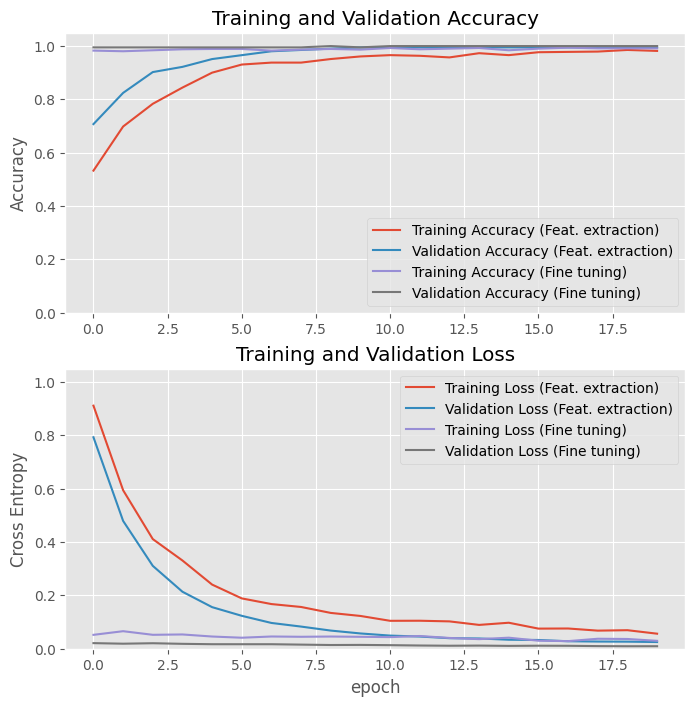

In [29]:
acc_ex = history.history['accuracy']
val_acc_ex = history.history['val_accuracy']
loss_ex = history.history['loss']
val_loss_ex = history.history['val_loss']

acc_ft = history_ft.history['accuracy']
val_acc_ft = history_ft.history['val_accuracy']
loss_ft = history_ft.history['loss']
val_loss_ft = history_ft.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc_ex, label='Training Accuracy (Feat. extraction)')
plt.plot(val_acc_ex, label='Validation Accuracy (Feat. extraction)')
plt.plot(acc_ft, label='Training Accuracy (Fine tuning)')
plt.plot(val_acc_ft, label='Validation Accuracy (Fine tuning)')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([0,1.05])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss_ex, label='Training Loss (Feat. extraction)')
plt.plot(val_loss_ex, label='Validation Loss (Feat. extraction)')
plt.plot(loss_ft, label='Training Loss (Fine tuning)')
plt.plot(val_loss_ft, label='Validation Loss (Fine tuning)')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.05])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

The model that we have configured to use the ResNet50 architecture as the base, with a feature extraction layer followed by a Dropout layer and a dense layer (designed for classification tasks with a single neuron) and updating all the weights (23,536,641 trainable out of 23,589,761 in total compared with the previous 2,049) at training time shows faster convergence and improved stability in performance throughout the training "epochs", with validation reaching and holding the "accuracy" at 99.51%, even getting to 100% at several points. This indicates reduced overfitting and better generalization compared with the previous results.

The best "epoch" was number 20 with:

loss: 0.0296

accuracy: 0.9915

val_loss: 0.0094

val_accuracy: 1.0000

The training results show a rapid improvement in the loss and "accuracy" metrics, for both training and validation, which is indicative of a good fit.

The validation "accuracy" reaches 100% several times throughout the training, which suggests that the model is extremely competent at correctly classifying the validation data. This is a sign that the validation set is really effective.

These results suggest that the new model is more efficient and effective both in fitting the training data and in generalizing to the validation data, due to a better update of the weights during training, which has allowed the model to better capture the patterns in the data.

Training and validation plot:

During the initial feature extraction phase, the "accuracy" and the loss in training and validation show a trend of steady improvement and then stabilize. This indicates that they are well trained and that only the final output needs to be slightly adjusted to the new labels.

After implementing the update of all the weights, a further improvement is observed in the "accuracy" and the loss for validation and training. This suggests that the tuning has allowed the model to adapt better to the specific characteristics of the current dataset, which indicates that the feature extraction was already providing a solid foundation.








## 3. Object localization by bounding-box regression on Fashion-MNIST

A CNN takes an image as input and outputs four values (x, y, width, height) defining the object's bounding box. The dataset generator, visualization helper, prediction snippet and IoU function in this section were provided by the course materials; the models, training and the accuracy function are my own.

In [30]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from skimage.transform import resize
import matplotlib.pyplot as plt

### Dataset generator (provided by course materials)

In [31]:
# Provided by course materials
class FashionMNISTlocalizationDataset(keras.utils.Sequence):
    """Fashion-MNIST localization toy dataset. Generates data for Keras."""

    def __init__(self, imgsize=(64,64), training=True, batch_size=32,
                 shuffle=True):
        """
        Args:
            imgsize (tuple (int,int), optional) - the size of generated images,
                both width and height, must be > 48x48.
            training (bool, optional) – If True, creates dataset from Fashion-MNIST
                training samples, otherwise from test.
            batch_size (int, optional) - the number of images in each generated
                batch.
            shuffle (bool, optional) - If True, the dataset is randomly shuffled
                at every epoch.
        """
        assert len(imgsize)==2 and imgsize[0] > 48 and imgsize[1] > 48
        self.imgsize = imgsize
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.training = training

        # load the Fashion-MNIST dataset (train or test split)
        if training:
          (self.data, self.labels), (_,_) = keras.datasets.fashion_mnist.load_data()
        else:
          (_,_), (self.data, self.labels) = keras.datasets.fashion_mnist.load_data()

        # Normalization
        self.data = self.data/255.

        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return int(np.floor(self.data.shape[0] / self.batch_size))

    def __getitem__(self, idx):
        'Generate one batch of data'
        # Generate indexes of the batch
        indexes = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]

        X = [] # batch of images
        y = [] # batch of target values

        # Generate data
        for index in indexes:
            # create a black image
            image = np.zeros(self.imgsize)
            image_width, image_height = self.imgsize
            # add some noise (to make the localization more dificult)
            image += np.random.random(self.imgsize)
            image = np.clip(image, 0., 1.)

            # Get one Fashion-MNIST object, resize it randomly, and copy it into
            # a random location of the black image
            object_img = self.data[index,:,:]
            object_width  = np.random.randint(12,48)
            object_height = np.random.randint(12,48)
            object_img = resize(object_img, (object_height, object_width))
            x_offset = np.random.randint(0,image_width-object_width)
            y_offset = np.random.randint(0,image_height-object_height)
            image[y_offset:y_offset+object_height, x_offset:x_offset+object_width] += object_img

            image = image.reshape(self.imgsize+(1,)) # must be a tensor image of size (width, height, channels)

            # normalize the target values (bounding box coordinates) so they are real numbers from 0. to 1.
            bbox = np.array([x_offset / image_width, y_offset / image_height,
                         object_width / image_width, object_height / image_height], dtype=np.float32)

            X.append(image)
            y.append(bbox)

        return np.array(X), np.array(y)

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(self.data.shape[0])
        if (self.shuffle == True) and (self.training == True):
            np.random.shuffle(self.indexes)


In [32]:
imgsize = (64,64)
batch_size = 32

# Create the data generators
training_generator = FashionMNISTlocalizationDataset(imgsize=imgsize,batch_size=batch_size)
validation_generator = FashionMNISTlocalizationDataset(imgsize=imgsize,training=False,batch_size=batch_size)

# Check the len and batch data shapes
print(training_generator.__len__(), validation_generator.__len__())
X,y = training_generator.__getitem__(0)
print(X.shape, y.shape)

4422102/4422102 [==============================] - 1s 0us/step
1875 312
(32, 64, 64, 1) (32, 4)


### Bounding-box visualization helper (provided by course materials)

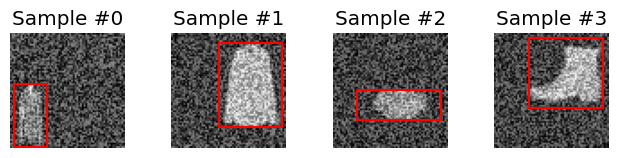

In [33]:
# Provided by course materials
def show_bbox(image, bbox, pred=None):
    """Show image with bbox"""
    image = image.squeeze()
    plt.imshow(image, cmap='gray')

    # plot the ground truth bounding box
    imgsize = image.shape
    bbox *= [imgsize[0],imgsize[1],imgsize[0],imgsize[1]]
    plt.plot([bbox[0],bbox[0]+bbox[2],bbox[0]+bbox[2],bbox[0],bbox[0]],
             [bbox[1],bbox[1],bbox[1]+bbox[3],bbox[1]+bbox[3],bbox[1]], c='r')

    if pred is not None:
        # plot the predicted bounding box (if provided)
        pred *= [imgsize[0],imgsize[1],imgsize[0],imgsize[1]]
        plt.plot([pred[0],pred[0]+pred[2],pred[0]+pred[2],pred[0],pred[0]],
                 [pred[1],pred[1],pred[1]+pred[3],pred[1]+pred[3],pred[1]], c='b')


X,y = training_generator.__getitem__(0)
fig = plt.figure()
for i in range(4):
    sample = {}
    sample['image'] = X[i,...]
    sample['bbox']  = y[i,...]
    #print(i, sample['image'].shape, sample['bbox'].shape)
    ax = plt.subplot(1, 4, i + 1)
    plt.tight_layout()
    ax.set_title('Sample #{}'.format(i))
    ax.axis('off')
    show_bbox(**sample)

plt.show()


### 3.1 Regression CNN: model definition

In [34]:
def create_model(input_shape):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(4, activation='sigmoid'))  # 4 neurons for (x, y, width, height)
    return model

# Create the model with the appropriate input shape
input_shape = (64, 64, 1)
model = create_model(input_shape)
model.summary()



Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 62, 62, 32)        320       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 31, 31, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 12544)             0         
                                                                 
 dense_5 (Dense)             (None, 128)              

#### Compilation

In [35]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

#### Training

In [36]:
# Provided by course materials
# Train model on dataset
imgsize = (64, 64)
batch_size = 32
training_generator = FashionMNISTlocalizationDataset(imgsize=imgsize, batch_size=batch_size)
validation_generator = FashionMNISTlocalizationDataset(imgsize=imgsize, training=False, batch_size=batch_size)

# Train the model
history = model.fit(training_generator, validation_data=validation_generator, epochs=6)



Epoch 1/6
1875/1875 [==============================] - 42s 21ms/step - loss: 0.0094 - accuracy: 0.6883 - val_loss: 0.0065 - val_accuracy: 0.7451
Epoch 2/6
1875/1875 [==============================] - 39s 21ms/step - loss: 0.0061 - accuracy: 0.7554 - val_loss: 0.0055 - val_accuracy: 0.7739
Epoch 3/6
1875/1875 [==============================] - 39s 21ms/step - loss: 0.0051 - accuracy: 0.7773 - val_loss: 0.0049 - val_accuracy: 0.7833
Epoch 4/6
1875/1875 [==============================] - 39s 21ms/step - loss: 0.0046 - accuracy: 0.7883 - val_loss: 0.0044 - val_accuracy: 0.7892
Epoch 5/6
1875/1875 [==============================] - 39s 21ms/step - loss: 0.0043 - accuracy: 0.7995 - val_loss: 0.0040 - val_accuracy: 0.8004
Epoch 6/6
1875/1875 [==============================] - 38s 21ms/step - loss: 0.0040 - accuracy: 0.8039 - val_loss: 0.0037 - val_accuracy: 0.8112


#### Loss curves

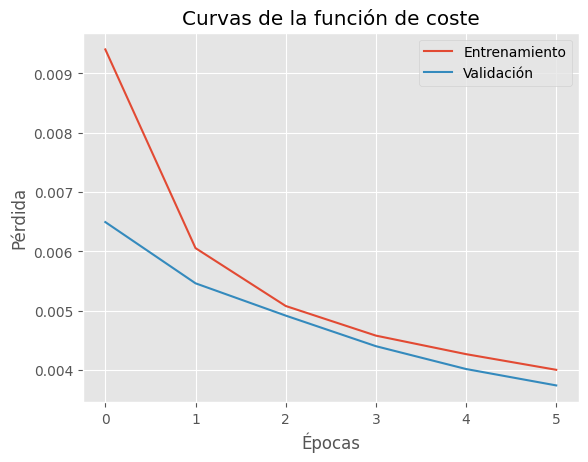

In [37]:
# Visualize the cost function curves
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Curvas de la función de coste')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()


### 3.2 Predictions and IoU-based evaluation

1/1 [==============================] - 0s 157ms/step


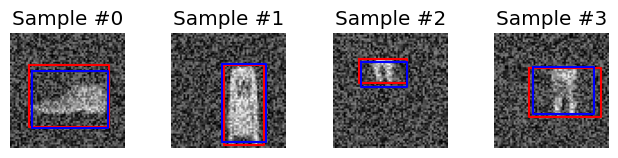

In [38]:
# Provided by course materials
def show_bbox(image, bbox, pred=None):
    image = image.squeeze()
    plt.imshow(image, cmap='gray')
    imgsize = image.shape
    bbox *= [imgsize[0], imgsize[1], imgsize[0], imgsize[1]]
    plt.plot([bbox[0], bbox[0]+bbox[2], bbox[0]+bbox[2], bbox[0], bbox[0]],
             [bbox[1], bbox[1], bbox[1]+bbox[3], bbox[1]+bbox[3], bbox[1]], c='r')
    if pred is not None:
        pred *= [imgsize[0], imgsize[1], imgsize[0], imgsize[1]]
        plt.plot([pred[0], pred[0]+pred[2], pred[0]+pred[2], pred[0], pred[0]],
                 [pred[1], pred[1], pred[1]+pred[3], pred[1]+pred[3], pred[1]], c='b')

# Make predictions and visualize
X, y = validation_generator.__getitem__(0)
preds = model.predict(X)
fig = plt.figure()
for i in range(4):
    sample = {'image': X[i, ...], 'bbox': y[i, ...]}
    ax = plt.subplot(1, 4, i + 1)
    plt.tight_layout()
    ax.set_title('Sample #{}'.format(i))
    ax.axis('off')
    show_bbox(sample['image'], sample['bbox'], preds[i])
plt.show()

#### IoU metric (provided by course materials)

In [39]:
# Provided by course materials
def IoU(pred, target, iou_threshold = 0.7):
    # determine the coordinates of the intersection rectangle
    x_left = np.maximum(pred[:,0], target[:,0])
    y_top = np.maximum(pred[:,1], target[:,1])
    x_right = np.minimum(pred[:,0]+pred[:,2], target[:,0]+target[:,2])
    y_bottom = np.minimum(pred[:,1]+pred[:,3], target[:,1]+target[:,3])

    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # compute the areas of the union
    pred_area = pred[:,2] * pred[:,3]
    target_area =  target[:,2] *  target[:,3]

    union_area = pred_area + target_area - intersection_area

    iou = intersection_area / union_area

    return iou>iou_threshold

In [40]:
# Provided by course materials
a = np.array([[0,0,1,1]])
b = np.array([[0,1,0.5,0.5]])
c = np.array([[0.1,0.1,0.85,0.85]])

print(IoU(a, a), IoU(a,b), IoU(a,c))

[ True] [False] [ True]


In [41]:
# Provided by course materials
a = np.random.random((32,4))
b = np.random.random((32,4))

IoU(a,b)

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False])

#### Accuracy over the validation set

In [42]:
def test(model, data_generator):
    total = 0
    correct = 0
    for X, y in data_generator:
        preds = model.predict(X)
        correct += np.sum(IoU(preds, y))
        total += X.shape[0]
    accuracy = correct / total * 100
    return accuracy



In [43]:
# call the test method
acc = test(model, validation_generator)
print('\nTest set: Accuracy: {:.0f}%\n'.format(acc))

1/1 [==============================] - 0s 17ms/step

Test set: Accuracy: 67%



### 3.3 Analysis


a)

The architecture used was a simple convolutional neural network (CNN), which consists of the following layers:

Two convolutional layers with ReLU activation, followed by pooling layers.
A flattening layer to flatten the outputs of the convolutional layers.
Two dense layers, one with ReLU activation and the final layer with sigmoid activation to produce the coordinates of the bounding box (x, y, width, height).

The convolutional layers with pooling help to extract important features from the images and reduce the dimensionality, which is useful for pattern recognition.
The use of ReLU works well for deep networks, providing non-linearity and helping to avoid the vanishing gradient problem.

The Adam optimizer is efficient when it comes to optimizing the adjustment of the learning in an adaptive way.


b)

The accuracy obtained is 67% on the validation set.

The network has a relatively simple structure, which makes for fast training but may limit the ability to capture more complex features. With more layers and parameters, a better generalization ability could be expected at the cost of a longer training time.

The reported training times are reasonable for this architecture and data size. As the complexity of the network is increased (more layers and neurons), the training time would increase considerably.

If architectures proposed on more complex datasets were used, an improvement in accuracy would be expected, but also an increase in training time and the need for greater computational capacity. It would be crucial to perform cross-validation and to use regularization techniques (such as dropout) to avoid overfitting.


c)

To adapt the model to perform both the localization and the classification of the object, modifications such as the following should be made:

Multiple outputs: One for the regression (localization of the object) and another for the classification of the object.

The loss function must combine classification and regression losses, for example, using the weighted sum of the cross-entropy loss (for classification) and the mean squared error loss (for regression).


